In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# loading and preprocessing the dataset
df = pd.read_csv('../datasets.csv')

df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], format='%m/%d/%Y')

df = df.rename(columns={'Disaster Type': 'Incident type'})

df['year'] = df['Declaration Date'].dt.year
df['month'] = df['Declaration Date'].dt.month

print(df['Declaration Date'].isna().sum(), "missing dates found.")
yearly_counts = df.groupby('year').size()
type_trends = df.groupby(['year', 'Incident type']).size().unstack(fill_value=0)



0 missing dates found.


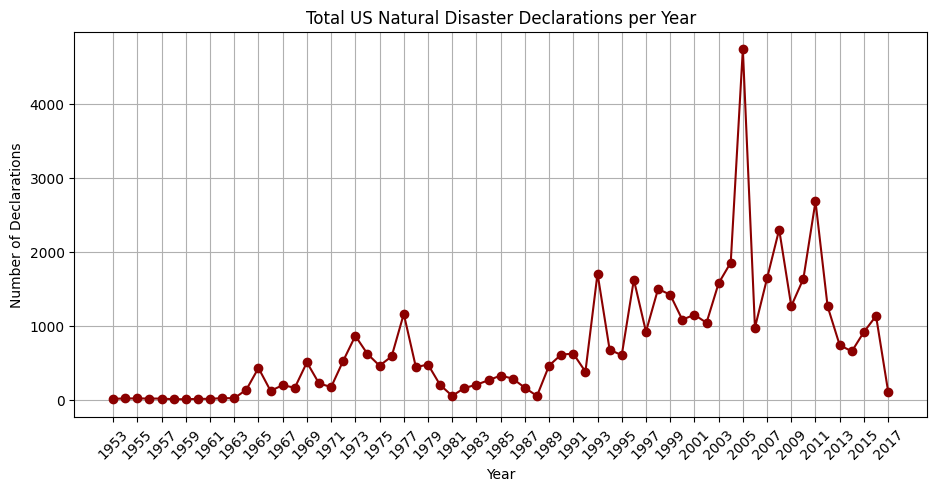

In [15]:
#visualizing the total number of declarations per year
plt.figure(figsize=(11, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o', color='darkred')
plt.xticks(range(int(yearly_counts.index.min()), int(yearly_counts.index.max()) + 1, 2), rotation=45)
plt.title('Total US Natural Disaster Declarations per Year')
plt.xlabel('Year')
plt.ylabel('Number of Declarations')
plt.grid(True)
plt.show()

1. The line-chart displays the total number of disaster declarations in United States on annual basis from year 1953-2017

2. The pattern is a long-term increasing trend where we can see a massive spike of incident declarations in the year 2005.

3. The reason is likely due to frequent extreme weather and expanded federal reporting, while the 2005 spike is likely due to massive incident reportings.

**Justifications:**

4. Is there an increasing trend?

    Yes.We can see an increasing trend from 60's which disappeared around 80's but we can see another increasing trend starting from 90's compared to the 60's.

5. Any sudden spikes?

    Yes.Followed by the increasing trend we observed a massive spike in the year 2005.By referring the disaster type data in the year we see a unprecedented volume of Hurricane and Flood declarations that year.

6. Any abnormal drops?

    Yes.There is a sharp drop in 2006.It is likely becuase the incidents occured in 2005 haven't repeated in the succeeding year and led to the massive drop of incidetns recorded.

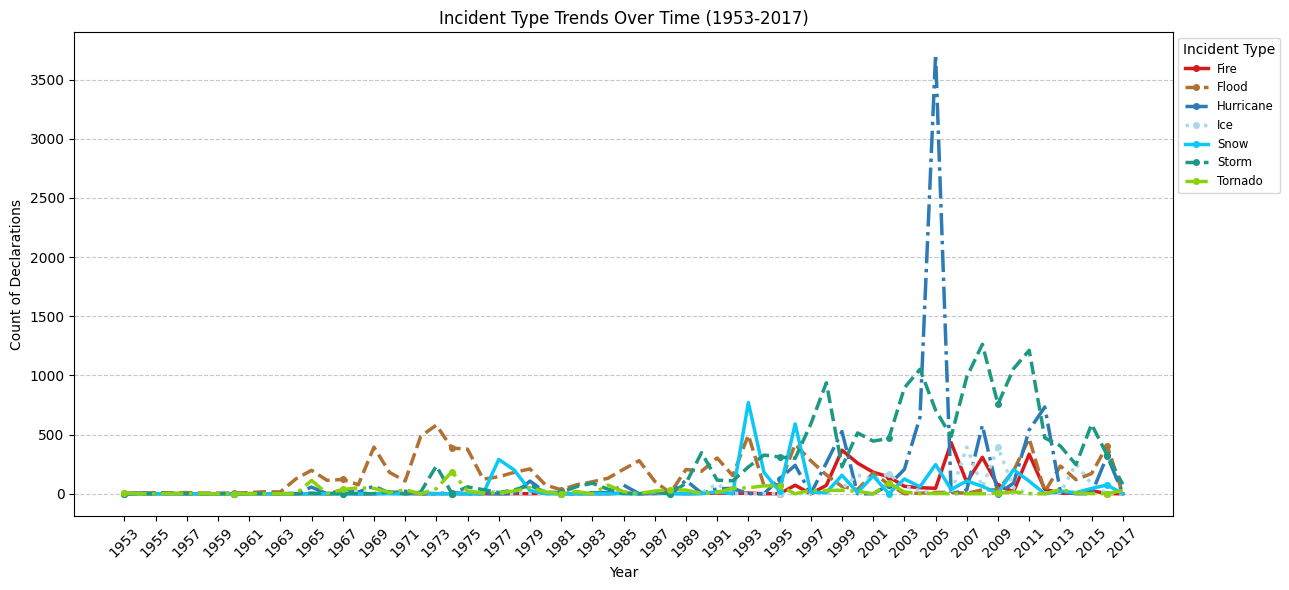

In [23]:
#visualizing trends for the top 7 incident types over time
plt.figure(figsize=(13, 6))
type_counts = df['Incident type'].value_counts().head(7).index
type_trends = df[df['Incident type'].isin(type_counts)].groupby(['year', 'Incident type']).size().unstack(fill_value=0)

colors = ['#d7191c', "#b07133", '#2c7bb6', '#abd9e9', "#0bc8f7", "#1c9982", "#8cd10d"]
line_styles = ['-', '--', '-.', ':']

#loop to plot each incident type with different colors and line styles
for i, column in enumerate(type_trends.columns):
    plt.plot(type_trends.index, 
             type_trends[column], 
             label=column, 
             color=colors[i], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5,
             marker='o', 
             markersize=4, 
             markevery=7)

plt.title('Incident Type Trends Over Time (1953-2017)')
plt.xlabel('Year')
plt.ylabel('Count of Declarations')
plt.xticks(range(int(type_trends.index.min()), int(type_trends.index.max()) + 1, 2), rotation=45)
plt.legend(title='Incident Type', bbox_to_anchor=(1, 1), loc='upper left', fontsize='small')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1. This multiline chart compares annual frequency of top 7 most reported incidents from 1954-2017.

2. Hurricanes and Storms consistently show the highest count and where floods although not high, did show a consistent level of reportings.

3. These incidents are the most frequent because they affect large geographical regions simultaneously and occur across most seasons in the US.

**Justifications:**

4. Which disaster type is most frequent?
    
    Floods were frequent till 90's and storms were the most frequent among all disasters occured.

5. Which type is increasing fastest?
    
    Hurricanes and storms are seen to be increasing the fastest with their frequncy doubling in the  lates 80's and 90's with a sudden surge in later years.

6. Any type declining?
    
    Snow is seen declining just after its sudden rush in 90's and Tornadoes are seen to be the constantly the lowest recordings of among top 7.

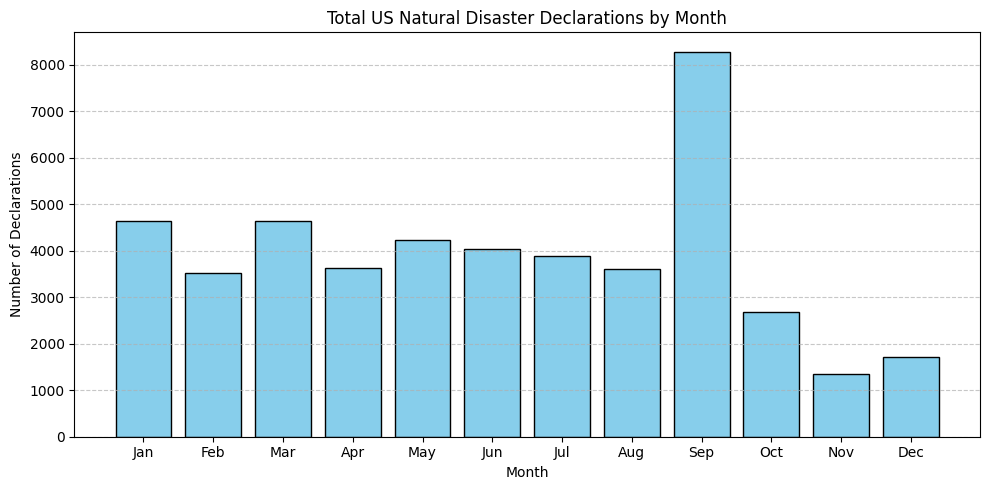

In [4]:

#visualizing the total number of declarations by month
plt.figure(figsize=(10, 5))
monthly_counts = df.groupby('month').size()
plt.bar(monthly_counts.index, monthly_counts.values, color='skyblue',edgecolor='black')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Total US Natural Disaster Declarations by Month')
plt.xlabel('Month')
plt.ylabel('Number of Declarations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() 


1. This bar chart illustrates the total volume of disaster declarations grouped by month over the time period of 1953-2017.

2. We can see a seasonal pattern that everytime a season changes the disaster count increases and then shows a downward trend.

3. Starting with the peak month Sep which is Fall,follows a downward trend and increases in Dec-Jan then decreases in Feb, similarly Mar(Spring) and May(late Spring or Summer) have an increase in the start and decline as seasons.

**Justifications:**

4. Which months have highest disasters?

    September has the highest disaster count followed by January and March both being seen at a similar peak and can be considered as second highest disaster occuring months.

5. Are disasters seasonal?

    Yes. Disasters are seasonal. In winter we can observe snow, blizzards and in early spring snow melts and floods occur and in Summer wildfire, storms and droughts take place and finally Late Summer/Early Fall where hurricanes occur which are affecting a massive amount of places.

6. Any recurring pattern?

    The data shows a recurring Triple-Peak cycle tied to the change of seasons. The most consistent pattern is the September surge, where hurricane landfalls cause a massive statistical explosion, followed by predictable smaller peaks in January and March driven by winter storms and spring snowmelt.




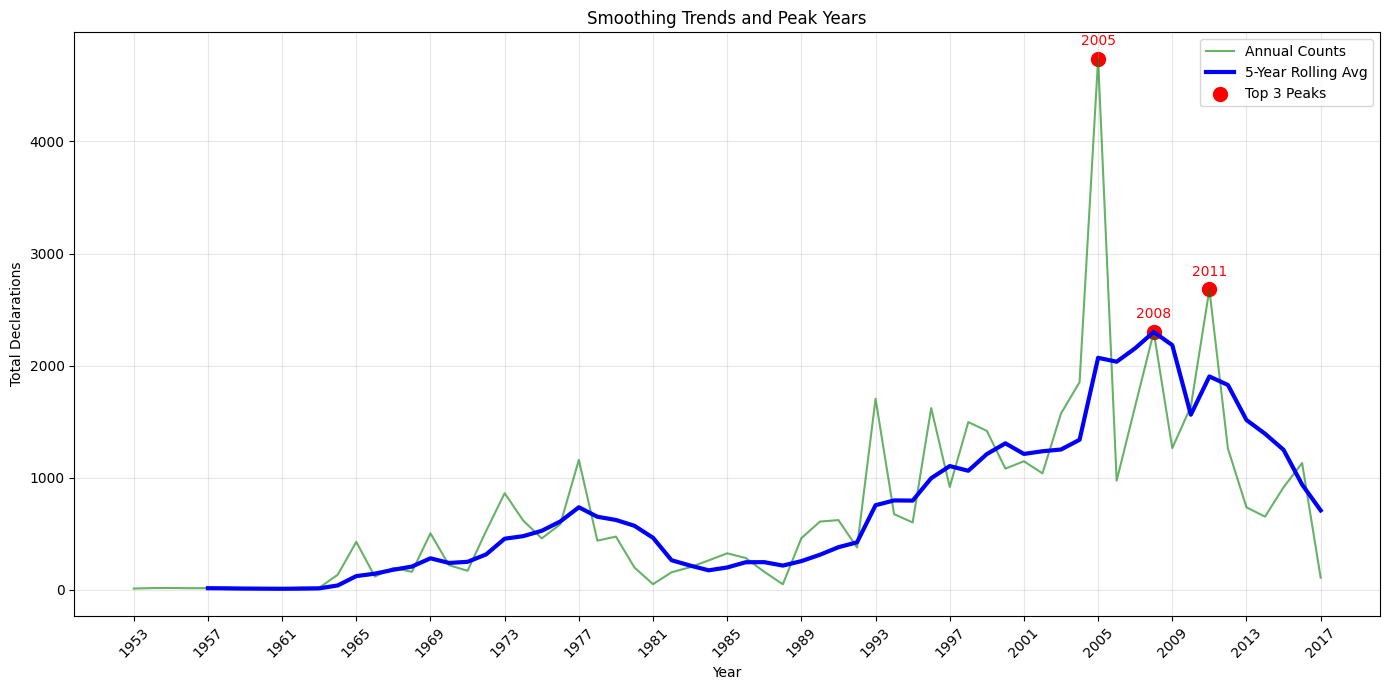

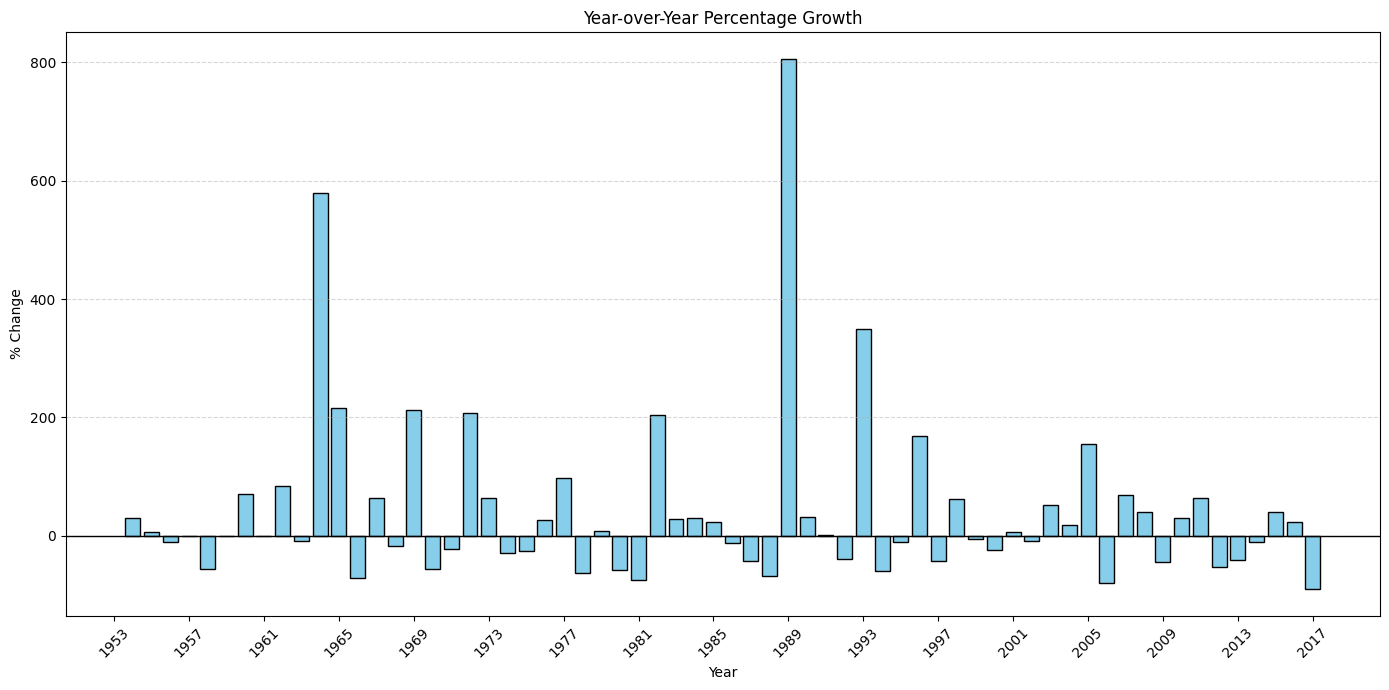

Maximum Growth Year: 1989 (805.88%)
Top 3 Disaster Peaks: 
year
2005    4736
2011    2680
2008    2300
dtype: int64


In [47]:
rolling_avg = yearly_counts.rolling(window=5).mean()

growth_rate = yearly_counts.pct_change() * 100

peaks = yearly_counts.nlargest(3)

plt.figure(figsize=(14, 7))
plt.plot(yearly_counts.index, yearly_counts.values, label='Annual Counts', color='green', alpha=0.6)
plt.plot(rolling_avg.index, rolling_avg.values, label='5-Year Rolling Avg', color='blue', linewidth=3)
plt.scatter(peaks.index, peaks.values, color='red', s=100, label='Top 3 Peaks')

for year, value in peaks.items():
    plt.annotate(f'{year}', (year, value), textcoords="offset points", xytext=(0,10), ha='center', color='red')

plt.title('Smoothing Trends and Peak Years')
plt.xlabel('Year')
plt.ylabel('Total Declarations')
plt.legend()
plt.xticks(range(int(yearly_counts.index.min()), int(yearly_counts.index.max()) + 1, 4), rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
plt.bar(growth_rate.index, growth_rate.values, color='skyblue', label='YoY % Growth', edgecolor='black')
plt.axhline(0, color='black', linewidth=1)

plt.title('Year-over-Year Percentage Growth')
plt.xlabel('Year')
plt.ylabel('% Change')
plt.xticks(range(int(yearly_counts.index.min()), int(yearly_counts.index.max()) + 1, 4), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Maximum Growth Year: {growth_rate.idxmax()} ({growth_rate.max():.2f}%)")
print(f"Top 3 Disaster Peaks: \n{peaks}")

1. These two visualizations show the long-term disaster trend smoothed by a 5-year rolling average and the Year-over-Year (YoY) percentage change, while specifically highlighting the Top 3 Peak Years.
2. While the raw data is volatile, the rolling average reveals a steady upward trajectory starting in the 1990s. The Growth Rate shows extreme shocks,with some years seeing disaster counts more than double (+100%) compared to the previous year.
3. The smoothened upward trend suggests systemic changes in climate and reporting, while the massive Year-Over-Year spikes are caused by rare, high-impact events like major hurricane seasons that temporarily overwhelm the baseline.